# BaseRAG Evaluation and Scaling Analysis

We evaluate the BaseRAG retrieval-augmented generation pipeline on a synthetic QA dataset derived from arXiv scientific papers. It loads a Self-Instruct–generated QA dataset, runs each query through the RAG system, and records retrieved contexts, generated answers, and fine-grained latency measurements (embedding, retrieval, generation, and total time). The resulting run logs are stored in JSONL format to support reproducible analysis.

The notebook then analyzes scalability and performance characteristics by plotting latency distributions (full, P95, P99) for each pipeline stage. In addition to performance analysis, it conducts qualitative and retrieval-quality evaluation using an LLM-as-judge setup to score retrieved chunks and generated answers, computing standard IR metrics such as Hit@K, Recall@K, and nDCG. Together, these experiments characterize the trade-offs between retrieval quality, generation accuracy, and system latency in large-scale RAG deployments.

In [23]:
import json
import math
import numpy as np
import pandas as pd
from pathlib import Path
from openai import OpenAI
from dotenv import load_dotenv
import random 
from datetime import datetime
import matplotlib.pyplot as plt

In [2]:
load_dotenv("keys.env")
client = OpenAI()  
MODEL = "gpt-5-nano"  
K = 5
N_QUERIES = 10
DATASET_NAME = "arxiv_scale_rag_self_instruct_v1"

In [3]:
from rag_core import BaseRAGPipeline

rag = BaseRAGPipeline(
    index_path="data/embeddings/rag_base_1000.index",
    emb_dir="data/embeddings/rag_embeddings_base_1000",
)

/home/mmk2266/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



🔹 Initializing RAG Pipeline...
Loading FAISS index...
FAISS index loaded with 34057 vectors.

Loading metadata...
Metadata loaded: 34057 rows.

Loading query encoder...
Encoder loaded.

Loading generator model...


`torch_dtype` is deprecated! Use `dtype` instead!
`flash-attention` package not found, consider installing for better performance: No module named 'flash_attn'.
Current `flash-attention` does not support `window_size`. Either upgrade or use `attn_implementation='eager'`.
Loading checkpoint shards: 100%|██████████| 2/2 [00:37<00:00, 18.64s/it]


Generator model loaded.



## 1) RAG Evaluation Loop

This function runs an end-to-end evaluation of the RAG pipeline over a question–answer dataset. For each query, it executes retrieval and generation using the configured RAG system, records the model’s answer along with the retrieved contexts, and logs fine-grained latency measurements (embedding, retrieval, generation, and total time). The output is a structured run log containing query metadata, gold answers, model responses, and performance timings, which can be saved as JSONL for downstream analysis of quality, latency, and scalability trade-offs.

In [4]:
def run_rag_eval(qna_dataset):
    run_log = []
    total = len(qna_dataset)

    for i, ex in enumerate(qna_dataset):
        q = ex["question"]
        gold = ex.get("answer")
        qid = ex.get("id")

        out = rag.run(q)

        run_log.append({
            "query_id": qid,
            "dataset": DATASET_NAME,
            "query": q,
            "gold_answer": gold,
            "answer": out["answer"],
            "contexts": out["contexts"],  # LIST (BaseRAG)
            "timing": out["timing"],
            "timestamp": datetime.utcnow().isoformat(),
        })

        if i % 10 == 0:
            print(f"Processed {i}/{total}")

    return run_log

In [5]:
DATASET_NAME = "arxiv_scale_rag_self_instruct_v1"

DATASET_PATH = Path("data/QnA/eval_qas_self_instruct.jsonl")
with DATASET_PATH.open("r", encoding="utf-8") as f:
    qna_dataset = [json.loads(line) for line in f]

In [6]:
random.seed(42)
qna_dataset_small = random.sample(qna_dataset, 100)
run_log = run_rag_eval(qna_dataset_small)

You are not running the flash-attention implementation, expect numerical differences.


Processed 0/100
Processed 10/100
Processed 20/100
Processed 30/100
Processed 40/100
Processed 50/100
Processed 60/100
Processed 70/100
Processed 80/100
Processed 90/100


In [12]:
save_dir = Path("data/QnA")
save_dir.mkdir(parents=True, exist_ok=True)

save_path = save_dir / "log_baseRAG_1000PDF.jsonl"

with save_path.open("w", encoding="utf-8") as f:
    for row in run_log:
        f.write(json.dumps(row) + "\n")

## 2) Scaling Results

In [15]:
log_path = Path("data/QnA/log_baseRAG_1000PDF.jsonl")

rows = []
with open(log_path, "r") as f:
    for i, line in enumerate(f):
        if i >= N_QUERIES:
            break
        rows.append(json.loads(line))

save_path = Path("data/QnA/log_scaleRAG_1000PDF_improved2.jsonl")

df = pd.DataFrame(rows)

In [18]:
df.head()

,query_id,dataset,query,gold_answer,answer,contexts,timing,timestamp
0,1904.08034v2_slice19_qa4,arxiv_scale_rag_self_instruct_v1,How is the G-rule defined relative to the F-ru...,The G-rule is defined deterministically given ...,The G-rule is defined relative to the F-rule b...,"[{'score': 0.7372968792915344, 'id': '2006.042...","{'embedding_ms': 7873.475822008913, 'retrieval...",2025-12-17T04:16:07.696174
1,1904.07640v1_slice22_qa4,arxiv_scale_rag_self_instruct_v1,What class of post-implant complication is add...,Particle disease.,Post-implant complication-free hazard ratios f...,"[{'score': 0.5012179017066956, 'id': '1904.076...","{'embedding_ms': 7803.35069001012, 'retrieval_...",2025-12-17T04:17:19.652229
2,1904.07640v1_slice5_qa0,arxiv_scale_rag_self_instruct_v1,What are the three entity/event types defined ...,Implant manufacturer/model entities; implant-r...,The three entity/event types defined in this s...,"[{'score': 0.5682927370071411, 'id': '2006.018...","{'embedding_ms': 779.1580589982914, 'retrieval...",2025-12-17T04:17:53.386047
3,1904.08049v1_slice20_qa4,arxiv_scale_rag_self_instruct_v1,"What formulation do LaMP methods approximate, ...",LaMP methods approximate the factored formulat...,The LaMP methods approximate the minimizing x ...,"[{'score': 0.6289060115814209, 'id': '1906.006...","{'embedding_ms': 603.0282409919892, 'retrieval...",2025-12-17T04:19:16.291462
4,1904.07698v2_slice21_qa1,arxiv_scale_rag_self_instruct_v1,What is the title and year of the paper by Bal...,Multimodal machine learning: A survey and taxo...,"The title of the paper by Baltruşaitis, Ahuja,...","[{'score': 0.3979908227920532, 'id': '1904.076...","{'embedding_ms': 788.6041640012991, 'retrieval...",2025-12-17T04:21:15.983719


In [20]:
df["embedding_ms"]  = df["timing"].apply(lambda x: x["embedding_ms"])
df["retrieval_ms"]  = df["timing"].apply(lambda x: x["retrieval_ms"])
df["generation_ms"] = df["timing"].apply(lambda x: x["generation_ms"])
df["total_ms"]      = df["timing"].apply(lambda x: x["total_ms"])

In [21]:
def plot_latency(lat, title_prefix, outname):
    p95, p99 = np.percentile(lat, [95, 99])

    subsets = [
        (lat, "Full"),
        (lat[lat <= p99], "P99"),
        (lat[lat <= p95], "P95"),
    ]

    fig, axes = plt.subplots(3, 1, figsize=(6, 7))

    for ax, (data, label) in zip(axes, subsets):
        ax.hist(data, bins=40 if label != "Full" else 50)
        ax.set_title(f"{title_prefix} ({label})")
        ax.set_xlabel("ms")
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.savefig(outname, dpi=300, bbox_inches="tight")
    plt.show()


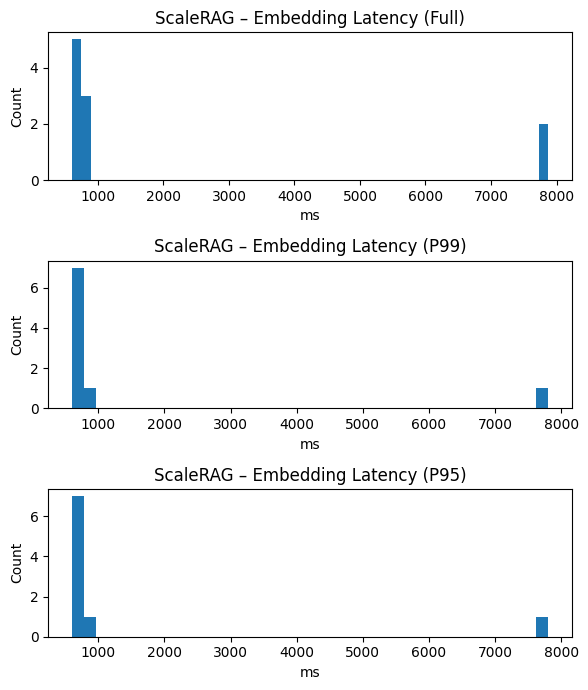

In [24]:
plot_latency(
    df["embedding_ms"].values,
    "ScaleRAG – Embedding Latency",
    "ScaleRAG_embedding_latency.png"
)

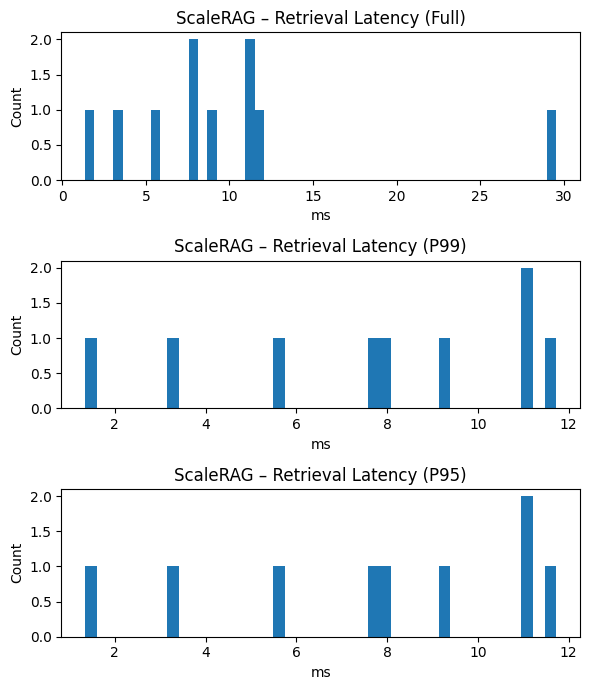

In [25]:
plot_latency(
    df["retrieval_ms"].values,
    "ScaleRAG – Retrieval Latency",
    "ScaleRAG_embedding_latency.png"
)

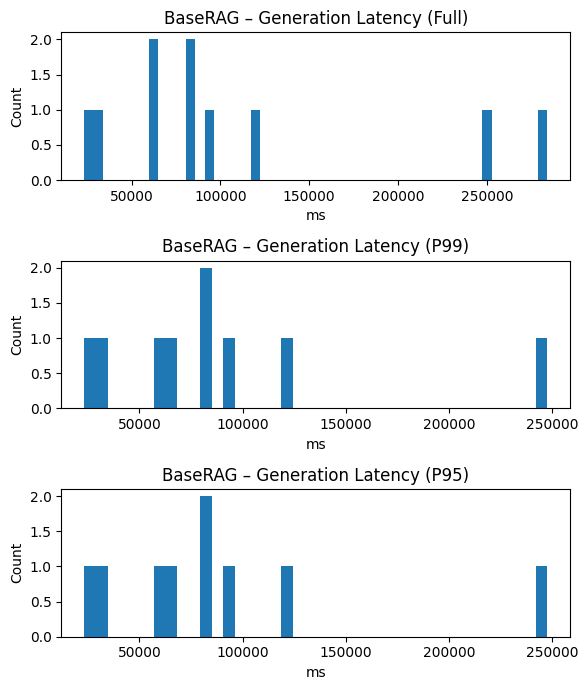

In [26]:
plot_latency(
    df["generation_ms"].values,
    "BaseRAG – Generation Latency",
    "BaseRAG1_generation_latency.png"
)

## 3) Qualitative Results

In [27]:
def extract_ranked_chunks(contexts_dict, k=5):
    """
    contexts_dict: dict with keys '0','1','2',...
    returns: list of chunk dicts in rank order (best first)
    """
    if not isinstance(contexts_dict, dict):
        return []

    # sort by numeric key, highest score last → reverse
    items = sorted(contexts_dict.items(), key=lambda x: int(x[0]))
    chunks = [v for _, v in items]

    # highest similarity is last → reverse
    chunks = list(reversed(chunks))

    return chunks[:k]

In [28]:
def build_chunk_text(ctx):
    parts = []
    if ctx.get("text_for_embedding"):
        parts.append(ctx["text_for_embedding"])
    if ctx.get("image_summary"):
        parts.append(f"[Image summary] {ctx['image_summary']}")
    return "\n".join(parts).strip()

In [29]:
def judge_query(query, gold_answer, pred_answer, contexts, model=MODEL):
    """
    contexts: list of retrieved chunks
              index 0 = lowest similarity
              index -1 = highest similarity
    """

    # contexts is a LIST → reverse to rank best → worst
    chunks = list(reversed(contexts))

    chunk_text = "\n\n".join(
        [
            f"[Chunk {i+1}]\n{c.get('text_for_embedding', '')}"
            for i, c in enumerate(chunks)
        ]
    )

    prompt = f"""
You are evaluating a Retrieval-Augmented Generation (RAG) system.

QUESTION:
{query}

GOLD ANSWER:
{gold_answer}

MODEL ANSWER:
{pred_answer}

RETRIEVED CHUNKS (ranked best to worst):
{chunk_text}

TASKS:
1. For each chunk, assign a relevance score:
   - 2 = directly supports the gold answer
   - 1 = partially relevant
   - 0 = irrelevant

2. Score the MODEL ANSWER from 0 to 1 based on correctness vs GOLD ANSWER.

Return JSON ONLY in this format:
{{
  "chunk_relevance": [r1, r2, r3, r4, r5],
  "answer_score": float
}}
"""

    resp = client.responses.create(
        model=model,
        input=prompt,
    )

    return json.loads(resp.output_text)


In [30]:
def dcg_at_k(rels, k):
    score = 0.0
    for i, rel in enumerate(rels[:k]):
        score += (2**rel - 1) / math.log2(i + 2)
    return score


def ndcg_at_k(rels, k):
    ideal = sorted(rels, reverse=True)
    denom = dcg_at_k(ideal, k)
    return 0.0 if denom == 0 else dcg_at_k(rels, k) / denom


def hit_at_k(rels, k, thresh=2):
    return 1 if any(r >= thresh for r in rels[:k]) else 0


def recall_at_k(rels, k, thresh=2):
    total_rel = sum(r >= thresh for r in rels)
    if total_rel == 0:
        return 0.0
    return sum(r >= thresh for r in rels[:k]) / total_rel

In [31]:
results = []

for row in rows:  
    out = judge_query(
        row["query"],
        row["gold_answer"],
        row["answer"],
        row["contexts"]
    )

    rels = out["chunk_relevance"]

    results.append({
        "hit@5": hit_at_k(rels, 5),
        "recall@5": recall_at_k(rels, 5),
        "dcg@5": dcg_at_k(rels, 5),
        "answer_score": out["answer_score"],
    })

In [32]:
df = pd.DataFrame(results)
summary = df.mean().to_frame(name="BaseRAG (N=10)")
summary

,BaseRAG (N=10)
hit@5,0.300000
recall@5,0.300000
dcg@5,0.986316
answer_score,0.135000
